In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import classification_report, accuracy_score

In [2]:
# Load the dataset with low_memory=False
df = pd.read_csv(r"C:\Users\Lokesh Patra\Documents\Projects\Major Project\cresci-2017.csv\cresci-2017\sytnth\final_dataset.csv", low_memory=False)

In [3]:
# --- STEP 1: Initial Cleanup ---

# Drop duplicates if any
df.drop_duplicates(inplace=True)

# Lowercase column names (for consistency)
df.columns = df.columns.str.lower()

# Drop exact duplicate columns
df = df.loc[:, ~df.columns.duplicated()]

# Convert date columns to datetime
date_cols = ['created_at_x', 'created_at_y', 'updated_x', 'updated_y', 
             'timestamp_x', 'timestamp_y', 'crawled_at_x', 'crawled_at_y']
date_format = "%Y-%m-%d %H:%M:%S"  # Specify format if known
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], format=date_format, errors='coerce')

# Drop columns with all missing values
df = df.dropna(how='all', axis=1)

In [4]:
# --- STEP 2: Handle Missing Values ---
# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()

# Impute numerical columns
imputer_num = SimpleImputer(strategy="median")
valid_num_cols = [col for col in num_cols if df[col].notna().sum() > 0]
if valid_num_cols:
    df[valid_num_cols] = imputer_num.fit_transform(df[valid_num_cols])

# Impute categorical columns
imputer_cat = SimpleImputer(strategy="most_frequent")
valid_cat_cols = [col for col in cat_cols if df[col].notna().sum() > 0]
if valid_cat_cols:
    df[valid_cat_cols] = imputer_cat.fit_transform(df[valid_cat_cols])

# --- STEP 3: Validate ---
# Ensure column lengths match
df = df.loc[:, df.columns]

print("Data preprocessing completed successfully!")

Data preprocessing completed successfully!


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396027 entries, 0 to 396026
Data columns (total 64 columns):
 #   Column                              Non-Null Count   Dtype         
---  ------                              --------------   -----         
 0   user_id                             396027 non-null  float64       
 1   name                                396027 non-null  object        
 2   screen_name                         396027 non-null  object        
 3   statuses_count                      396027 non-null  float64       
 4   followers_count                     396027 non-null  float64       
 5   friends_count                       396027 non-null  float64       
 6   favourites_count                    396027 non-null  float64       
 7   listed_count                        396027 non-null  float64       
 8   created_at_x                        396027 non-null  datetime64[ns]
 9   url                                 396027 non-null  object        
 10  lang    

In [6]:
# --- STEP 3: Feature Engineering & Encoding ---

# Encode booleans
for col in df.select_dtypes(include='bool').columns:
    df[col] = df[col].astype(int)

# Label encode binary categoricals
le = LabelEncoder()
binary_cols = [col for col in cat_cols if df[col].nunique() == 2]  # Binary columns with exactly 2 unique values
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# Create new features if needed
df['follower_friend_ratio'] = df['followers_count'] / (df['friends_count'] + 1)  # Avoid division by zero
df['tweet_like_ratio'] = df['favorite_count'] / (df['statuses_count'] + 1)       # Avoid division by zero

# Clean 'description' text (optional for later NLP)
def clean_text(text):
    if pd.isna(text):
        return ''  # Handle NaN values
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)  # Remove URLs
    text = re.sub(r'\@[\w]*', '', text)  # Remove mentions
    text = re.sub(r'[^A-Za-z\s]', '', text)  # Remove special characters
    text = text.lower()  # Convert text to lowercase
    return text

if 'description' in df.columns:
    df['description_clean'] = df['description'].apply(clean_text)

In [7]:
df.describe()

,user_id,statuses_count,followers_count,friends_count,favourites_count,listed_count,created_at_x,default_profile,default_profile_image,geo_enabled,...,post_frequency_per_day,avg_word_count_per_post,avg_hashtags_per_post,avg_sentiment_score,reply_to_post_ratio,urls_per_post_ratio,bio_complexity_score,label,follower_friend_ratio,tweet_like_ratio
count,3.960270e+05,396027.000000,396027.000000,396027.000000,396027.000000,396027.000000,396027,396027.0,396027.0,396027.0,...,396027.000000,396027.000000,396027.000000,396027.000000,396027.000000,396027.000000,396027.000000,396027.000000,396027.000000,396027.000000
mean,5.590412e+08,7332.904724,1250.312774,1047.095284,1499.677820,11.489015,2011-08-17 06:05:09.774954752,1.0,1.0,1.0,...,25.069039,11.820992,0.203504,0.000664,0.017276,0.064007,0.499680,0.172400,2.602646,0.349150
min,6.780330e+05,0.000000,0.000000,0.000000,0.000000,0.000000,2007-01-22 01:57:38,1.0,1.0,1.0,...,0.100007,1.000000,0.000000,-0.999997,0.000000,0.000000,0.000001,0.000000,0.000000,0.000000
25%,1.936071e+08,79.000000,15.000000,266.000000,0.000000,0.000000,2010-09-22 07:25:17,1.0,1.0,1.0,...,12.569980,6.000000,0.000000,-0.499444,0.000000,0.000000,0.249502,0.000000,0.040678,0.000000
50%,4.663775e+08,819.000000,108.000000,543.000000,1.000000,0.000000,2012-01-17 10:22:46,1.0,1.0,1.0,...,25.081000,11.000000,0.000000,0.000866,0.000000,0.000000,0.499869,0.000000,0.239908,0.000000
75%,6.162854e+08,4538.000000,614.000000,856.000000,255.000000,4.000000,2012-06-23 15:50:57,1.0,1.0,1.0,...,37.559757,17.000000,0.000000,0.501908,0.000000,0.000000,0.750035,0.000000,0.941986,0.000000
max,2.525273e+09,333504.000000,986837.000000,45690.000000,185467.000000,4840.000000,2014-05-26 15:32:52,1.0,1.0,1.0,...,49.999811,142.000000,15.000000,1.000000,0.941176,0.857143,1.000000,1.000000,2108.333333,4665.482759
std,5.530482e+08,20917.660182,16053.999812,2126.601939,6195.394558,104.203574,NaN,0.0,0.0,0.0,...,14.423832,7.024416,0.635895,0.577775,0.091498,0.156614,0.288648,0.377728,48.873745,25.210681


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396027 entries, 0 to 396026
Data columns (total 67 columns):
 #   Column                              Non-Null Count   Dtype         
---  ------                              --------------   -----         
 0   user_id                             396027 non-null  float64       
 1   name                                396027 non-null  object        
 2   screen_name                         396027 non-null  object        
 3   statuses_count                      396027 non-null  float64       
 4   followers_count                     396027 non-null  float64       
 5   friends_count                       396027 non-null  float64       
 6   favourites_count                    396027 non-null  float64       
 7   listed_count                        396027 non-null  float64       
 8   created_at_x                        396027 non-null  datetime64[ns]
 9   url                                 396027 non-null  object        
 10  lang    

In [9]:
# --- STEP 4: Drop Unnecessary or Redundant Columns ---

# Step 1: Automatically drop low-variance columns
low_variance_cols = [col for col in df.columns if df[col].nunique() <= 1]

# Step 2: Manually drop identifiers or redundant features (images, URLs)
manual_drop_cols = [
    'user_id', 'profile_image_url', 'profile_banner_url',
    'profile_background_image_url', 'profile_background_image_url_https',
    'profile_image_url_https', 'url', 'source'
]

# Step 3: Optional: Drop high cardinality identifiers (if not used in NLP)
# If you plan to use name/screen_name in feature engineering, keep them
identifier_cols = ['name', 'screen_name']

# Combine and drop
final_drop_cols = low_variance_cols + manual_drop_cols  # + identifier_cols (optional)
df.drop(columns=[col for col in final_drop_cols if col in df.columns], inplace=True)

print("Dropped columns:", final_drop_cols)

Dropped columns: ['default_profile', 'default_profile_image', 'geo_enabled', 'profile_use_background_image', 'profile_background_tile', 'verified', 'possibly_sensitive', 'user_id', 'profile_image_url', 'profile_banner_url', 'profile_background_image_url', 'profile_background_image_url_https', 'profile_image_url_https', 'url', 'source']


In [10]:
low_variance_cols = [col for col in df.columns if df[col].nunique() <= 1]

low_variance_cols

[]

In [11]:
# --- STEP 5: Prepare Features and Labels ---
target_col = 'label'
X = df.drop(columns=[target_col])  # Features
y = df[target_col].astype(int)     # Target labels

In [12]:
# --- Optional Scaling ---
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X.select_dtypes(include=['float64', 'int64'])), 
                        columns=X.select_dtypes(include=['float64', 'int64']).columns)

# Reattach non-scaled features (categoricals etc.)
X_final = pd.concat([X_scaled, X.drop(columns=X_scaled.columns)], axis=1)

# --- Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42, stratify=y)

print("Data cleaned and ready! Shapes:", X_train.shape, X_test.shape)

Data cleaned and ready! Shapes: (316821, 51) (79206, 51)


In [22]:
X_train.columns

Index(['statuses_count', 'followers_count', 'friends_count',
       'favourites_count', 'listed_count', 'utc_offset', 'test_set_1',
       'test_set_2', 'id', 'in_reply_to_status_id', 'in_reply_to_user_id',
       'retweeted_status_id', 'retweet_count', 'reply_count', 'favorite_count',
       'num_hashtags', 'num_urls', 'num_mentions', 'account_age_days',
       'following_count', 'post_frequency_per_day', 'avg_word_count_per_post',
       'avg_hashtags_per_post', 'avg_sentiment_score', 'reply_to_post_ratio',
       'urls_per_post_ratio', 'bio_complexity_score', 'follower_friend_ratio',
       'tweet_like_ratio', 'name', 'screen_name', 'created_at_x', 'lang',
       'time_zone', 'location', 'profile_text_color',
       'profile_sidebar_border_color', 'profile_sidebar_fill_color',
       'profile_background_color', 'profile_link_color', 'description',
       'updated_x', 'timestamp_x', 'crawled_at_x', 'text',
       'in_reply_to_screen_name', 'place', 'timestamp_y', 'crawled_at_y',
    

In [23]:
X_test.columns

Index(['statuses_count', 'followers_count', 'friends_count',
       'favourites_count', 'listed_count', 'utc_offset', 'test_set_1',
       'test_set_2', 'id', 'in_reply_to_status_id', 'in_reply_to_user_id',
       'retweeted_status_id', 'retweet_count', 'reply_count', 'favorite_count',
       'num_hashtags', 'num_urls', 'num_mentions', 'account_age_days',
       'following_count', 'post_frequency_per_day', 'avg_word_count_per_post',
       'avg_hashtags_per_post', 'avg_sentiment_score', 'reply_to_post_ratio',
       'urls_per_post_ratio', 'bio_complexity_score', 'follower_friend_ratio',
       'tweet_like_ratio', 'name', 'screen_name', 'created_at_x', 'lang',
       'time_zone', 'location', 'profile_text_color',
       'profile_sidebar_border_color', 'profile_sidebar_fill_color',
       'profile_background_color', 'profile_link_color', 'description',
       'updated_x', 'timestamp_x', 'crawled_at_x', 'text',
       'in_reply_to_screen_name', 'place', 'timestamp_y', 'crawled_at_y',
    

In [40]:
y_train.name

'label'

In [41]:
y_test.name

'label'

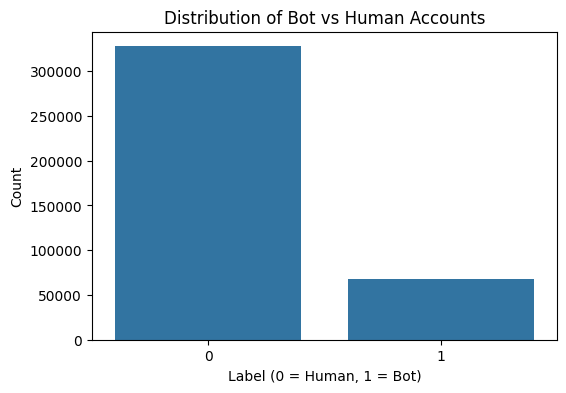

label
0    0.8276
1    0.1724
Name: proportion, dtype: float64


In [13]:
# STEP 6A: Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df)
plt.title('Distribution of Bot vs Human Accounts')
plt.xlabel('Label (0 = Human, 1 = Bot)')
plt.ylabel('Count')
plt.show()

print(df['label'].value_counts(normalize=True).rename('proportion'))

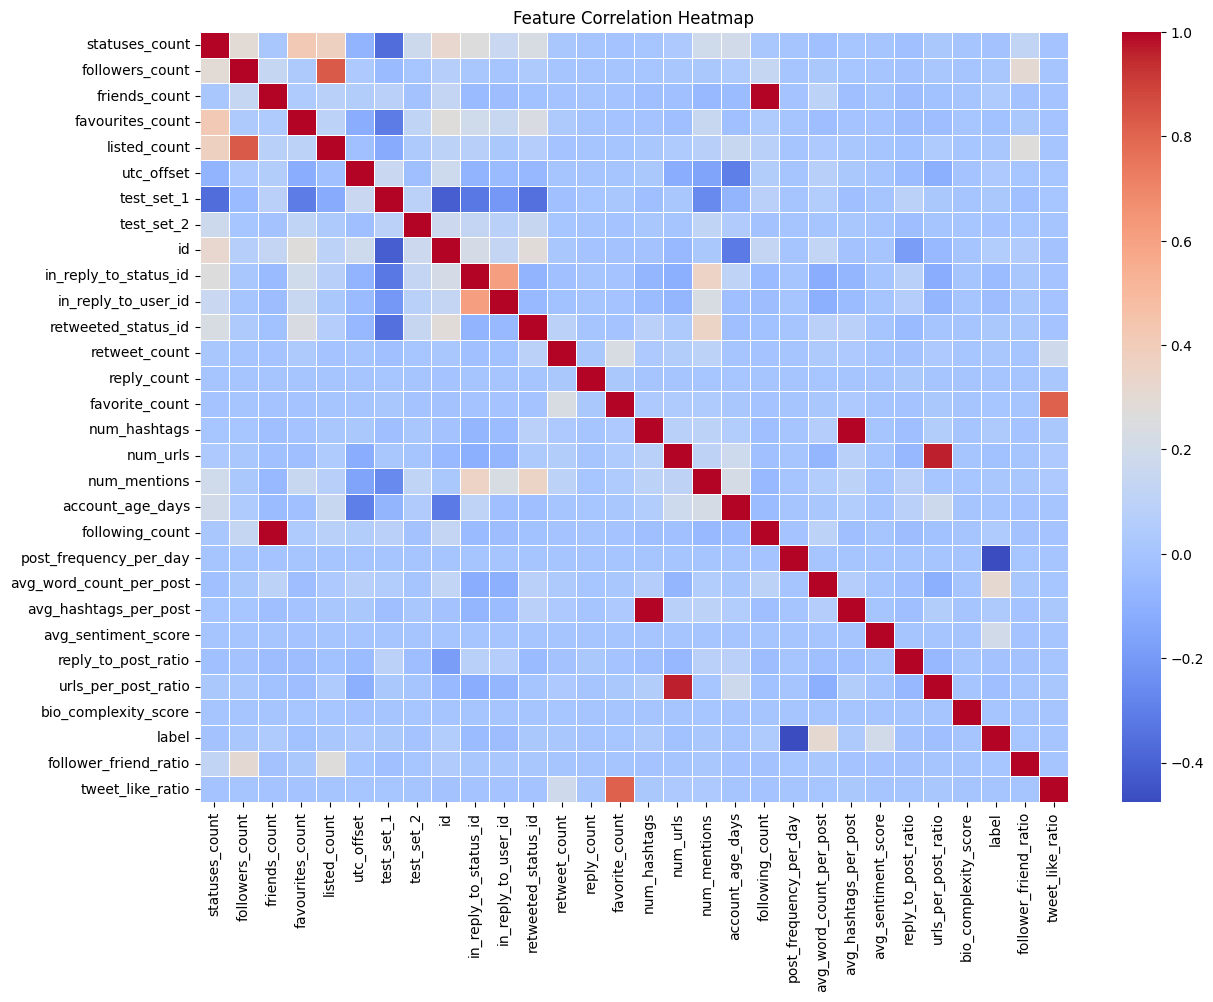

In [14]:
#STEP 6B: Correlation Heatmap (Numerics Only)

# Select numeric features only
numeric_df = df.select_dtypes(include=[np.number])

# Optional: Drop ID columns or unrelated large-scale IDs if left
corr = numeric_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', annot=False, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

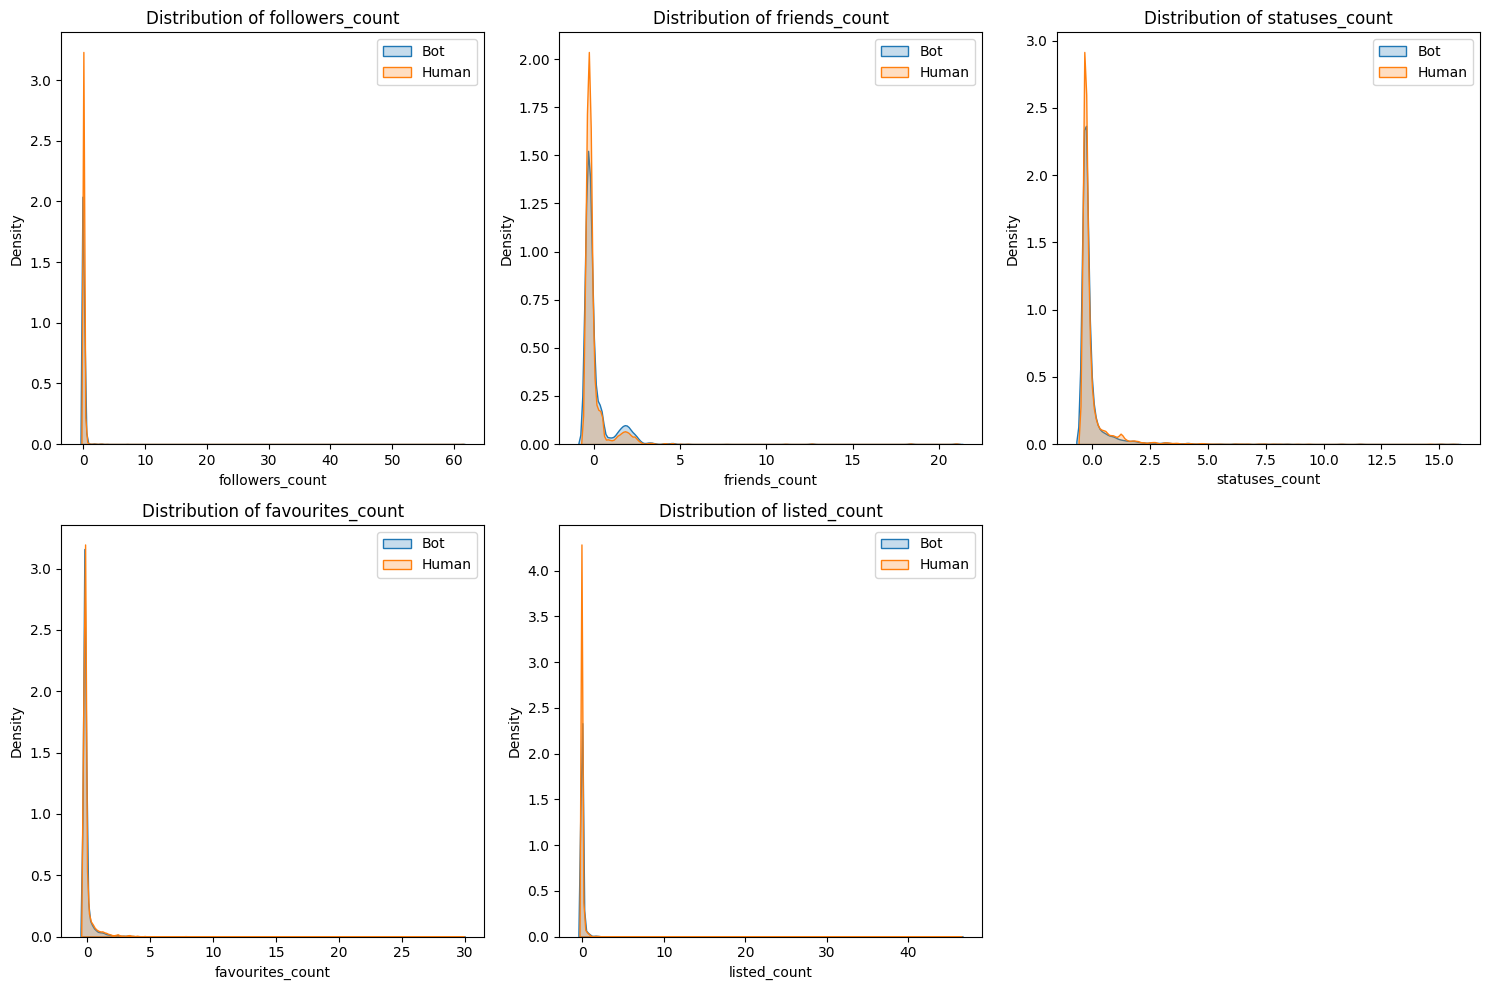

In [18]:
# STEP 6C: Feature Distributions (Bots vs Humans)

# Ensure the target column is included in X_train for analysis
X_train['label'] = y_train  # Attach labels back for visualization

bot_df = X_train[X_train['label'] == 1]  # Bots
human_df = X_train[X_train['label'] == 0]  # Humans

# Select features to visualize
top_feats = ['followers_count', 'friends_count', 'statuses_count', 
             'favourites_count', 'listed_count']

plt.figure(figsize=(15, 10))
for i, feat in enumerate(top_feats):
    if feat in X_train.columns:  # Check if feature exists
        plt.subplot(2, 3, i + 1)
        sns.kdeplot(bot_df[feat], label='Bot', fill=True)
        sns.kdeplot(human_df[feat], label='Human', fill=True)
        plt.title(f'Distribution of {feat}')
        plt.legend()
plt.tight_layout()
plt.show()

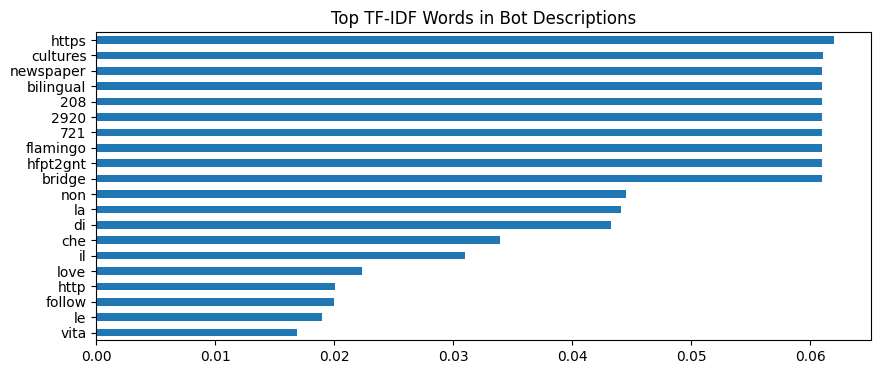

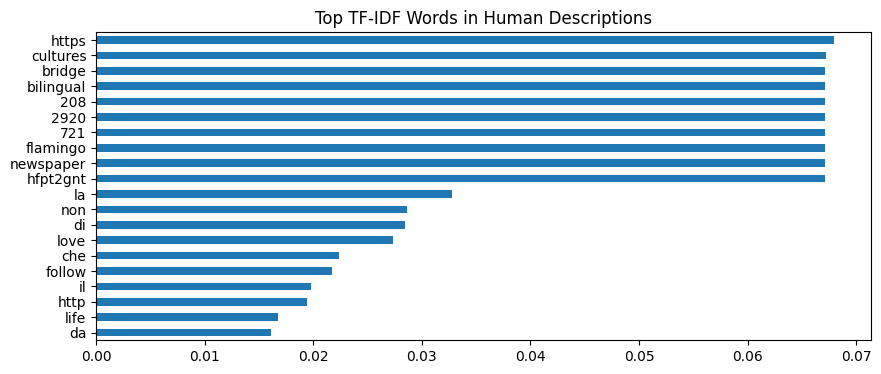

In [19]:
# STEP 6D: Top Words in Descriptions (TF-IDF)

# Fill NA
df['description'] = df['description'].fillna("")

# Vectorize description
vectorizer = TfidfVectorizer(max_features=100, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(df['description'])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())

# Top words for bots
bot_tfidf = tfidf_df[df['label'] == 1].mean().sort_values(ascending=False).head(20)

# Top words for humans
human_tfidf = tfidf_df[df['label'] == 0].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 4))
bot_tfidf.plot(kind='barh', title='Top TF-IDF Words in Bot Descriptions')
plt.gca().invert_yaxis()
plt.show()

plt.figure(figsize=(10, 4))
human_tfidf.plot(kind='barh', title='Top TF-IDF Words in Human Descriptions')
plt.gca().invert_yaxis()
plt.show()

In [25]:
#STEP 7: Feature Engineering

from sklearn.preprocessing import LabelEncoder

# Fill missing values
X_train['description_clean'] = X_train['description_clean'].fillna('')
X_test['description_clean'] = X_test['description_clean'].fillna('')
X_train['location'] = X_train['location'].fillna('unknown')
X_test['location'] = X_test['location'].fillna('unknown')

# Encode categorical columns safely using mapping
cat_cols = ['lang', 'time_zone', 'location']
le_dict = {}

for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    
    # Build mapping dictionary
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    
    # Map test values, use -1 for unknown categories
    X_test[col] = X_test[col].astype(str).map(mapping).fillna(-1).astype(int)
    
    le_dict[col] = le

In [26]:
tfidf = TfidfVectorizer(max_features=100, stop_words='english')

X_desc_train = tfidf.fit_transform(X_train['description_clean']).toarray()
X_desc_test = tfidf.transform(X_test['description_clean']).toarray()

# Drop original text column
X_train.drop(columns=['description_clean'], inplace=True)
X_test.drop(columns=['description_clean'], inplace=True)

# Add TF-IDF features
tfidf_cols = [f'tfidf_{i}' for i in range(X_desc_train.shape[1])]
X_train_tfidf = pd.DataFrame(X_desc_train, columns=tfidf_cols, index=X_train.index)
X_test_tfidf = pd.DataFrame(X_desc_test, columns=tfidf_cols, index=X_test.index)

X_train = pd.concat([X_train, X_train_tfidf], axis=1)
X_test = pd.concat([X_test, X_test_tfidf], axis=1)

In [30]:
# Step 1: Check which columns are non-numeric
non_numeric_cols = X_train.select_dtypes(include=['object']).columns
print("Non-numeric columns:", non_numeric_cols)

Non-numeric columns: Index(['name', 'screen_name', 'profile_text_color',
       'profile_sidebar_border_color', 'profile_sidebar_fill_color',
       'profile_background_color', 'profile_link_color', 'description', 'text',
       'in_reply_to_screen_name', 'place'],
      dtype='object')


In [31]:
# Drop them from both train and test
X_train = X_train.drop(columns=non_numeric_cols)
X_test = X_test.drop(columns=non_numeric_cols)

In [33]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)

In [42]:
ensemble.fit(X_train, y_train)
y_pred = ensemble.predict(X_test)

DTypePromotionError: The DType <class 'numpy.dtypes.DateTime64DType'> could not be promoted by <class 'numpy.dtypes.Float64DType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DT

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))